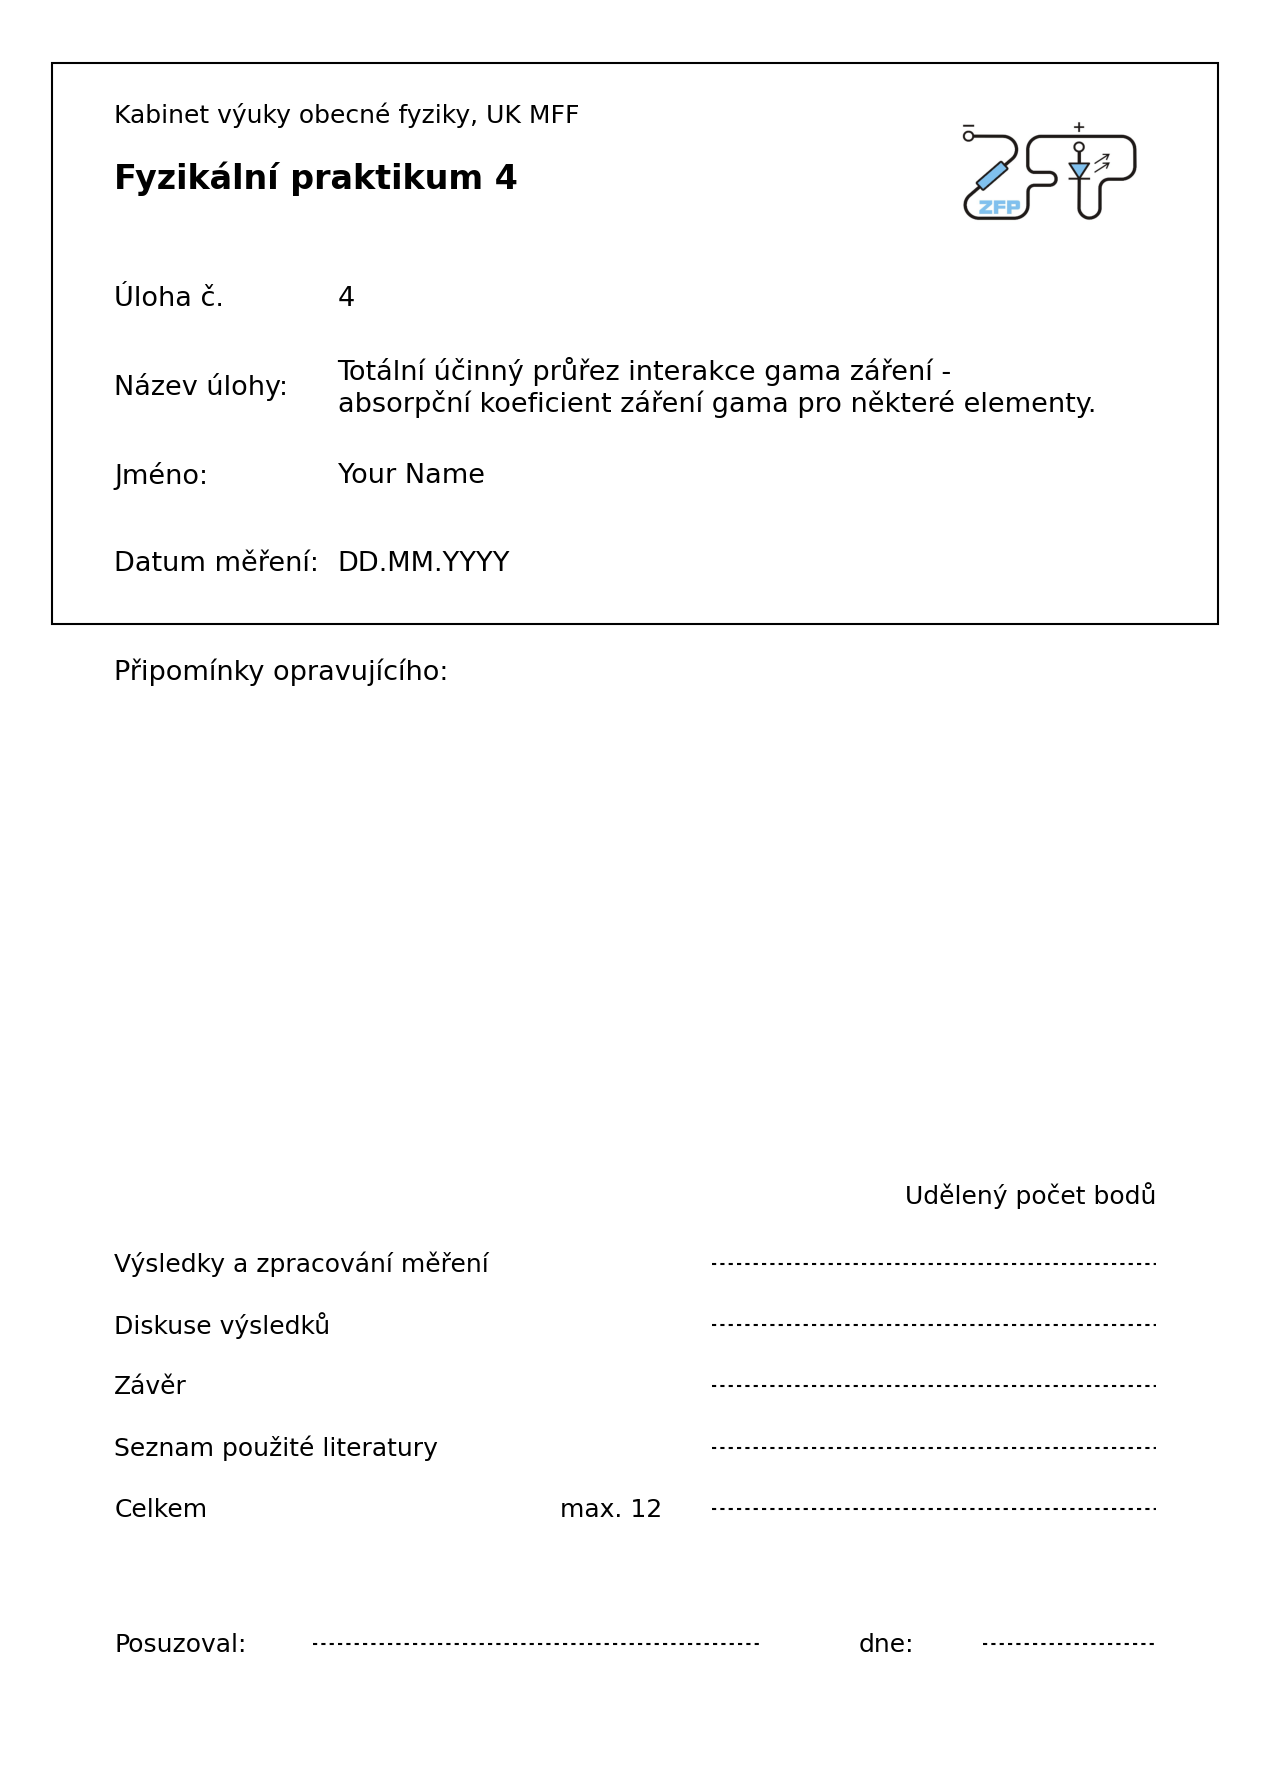

In [1]:
# TODO: Replace the string "Your Name" and "DD.MM.YYYY" with the appropriate values.

from header import header
_ = header(student = "Your Name", date = "DD.MM.YYYY", task_no = 4)

# Totální účinný průřez interakce gama záření - absorpční koeficient záření gama pro některé elementy

# Pracovní úkoly  

1. Určete absorpční koeficient záření $\gamma$ pro olovo, kadmium a železo v závislost na energii.

2. Stanovte polotloušťku výše uvedených materiálů pro energie dostatečně intenzivních přechodů používaného zářiče.

3. Srovnejte naměřené hodnoty absorpčního koeficientu s hodnotami tabulkovými pro olovo, kadmium a železo.

4. Diskutujte vliv jednotlivých interakcí $\gamma$ záření s látkou na naměřené hodnoty v používané experimentální geometrii.

# Úvod

Proces zeslabení svazku gama záření v prostředí nelze považovat za spojitý, jak je tomu u těžkých nabitých částic. Při interakci fotonu s elektrony atomového obalu prostředí buď foton ztratí veškerou svou energii fotoelektrickým jevem nebo tvorbou elektron-pozitronových párů, nebo její část Comptonovým (nekoherentním) rozptylem. Tvorba elektron-pozitronových párů může přirozeně probíhat také v poli jádra. Při koherentním rozptylu foton nedeponuje energii, ale mění směr. Při nekoherentním rozptylu kromě ztráty energie také mění směr. Důsledkem těchto interakcí pro experiment je zeslabení svazku gama záření při průchodu vrstvou materiálu tloušťky $t$ podle vztahu:
$$
N = N_0 e^{-\mu t},
$$
kde $N_0$ je počet gama kvant dopadajících na vrstvu materiálu tloušťky $t$, $N$ je počet fotonů s původní energií za vrstvou materiálu, $\mu$ je absorpční koeficient nebo lineární zeslabovací koeficient s rozměrem $\mathrm{mm}^{-1}$.
Protože závislost zeslabení svazku gama záření na tloušťce materiálu má exponenciální charakter, vždy existuje nenulová pravděpodobnost, že gama kvantum projde jakoukoli tloušťkou jakéhokoli materiálu bez interakce.
Pro každou danou energii dopadajících fotonů $E_\gamma$ se tak může volná dráha jednotlivých fotonů významně lišit od střední volné dráhy $1/\mu(E_\gamma)$.

Interakce elektromagnetického záření s hmotou je velmi dobře známa. Jednotlivé účinné průřezy jako funkce energie fotonu jsou mimo jiné tabelovány [1]. Závislost absorpčního koeficientu $\mu$ na energii dopadajících fotonů $E_\gamma$ je ukázána pro olovo na níže uvedeném obrázku. Pro konkrétní experimenty je často praktičtější určit zeslabení svazku experimentálně (pro konkrétní detektor, geometrii, ...) a případně jej ověřit pomocí počítačové simulace metodou Monte Carlo.

$\color{red}{\textbf{Úkol:}}$ Stáhněte si tabelovaná data. Upravte do námi používaných jednotek. Všimněte si, že tabelovaná data jsou v jednotkách $\mathrm{cm}^{2} / \mathrm{g}$. Pro jeden prvek vykreslete graf.

In [ ]:
# Solution.

# TODO: Choose the element from the choice of: "Pb", "Fe", "Cd".
element = 

# TODO: Finish scales below. Ask the instructor if you need help.
# Each element (Pb, Fe, Cd) should have an entry in the dictionary below.
# Example:
# scale = {'Xe': 5.894e-3 / 10.}
scale = 

# TODO: Set maximum of the x-axis range.
# Set it to cover the part of the graph where we perform measurements.
x_max = 

# TODO: Adjust the y-axis range if necessary.
y_min = 1e-4
y_max = 1e1

# Read.
import pandas as pd
from pathlib import Path
import re
import matplotlib.pyplot as plt

# Directory with theory data files.
DATA_DIR = Path("./data/")   # adjust if needed

# Column names in the data files.
COLS = ['E', 'sigma_R', 'sigma', 'tau', 'kappa_n', 'kappa_e', 'w', 'wo']

# Dictionary to hold DataFrames corresponding to each element we have data for.
dfs = {}

# Read in the theory values, and convert them to units of mm^-1.
# Convert units of E to keV.
for file in sorted(DATA_DIR.glob("*_theory_all.txt")):
    # Extract symbol from filename, e.g. Pb_theory_all.txt → Pb
    m = re.match(r"(?P<sym>[A-Za-z0-9]+)_theory_all\.txt$", file.name)
    symbol = m.group("sym") if m else file.stem

    # Read file (skip text header, ignore last empty column)
    df = pd.read_csv( file, sep=r"\s+", names=COLS, engine="python", usecols=range(8))

    # Convert and compute
    df['E'] *= 1000
    df.loc[:, df.columns != "E"] *= scale.get(symbol, 1.0) # use 1 if scale not defined
    df['kappa_tot'] = df['kappa_n'] + df['kappa_e']

    # Store for later use
    dfs[symbol] = df

# Now you can access them like:
dfs[element].head()

# Plot the curves.
fig, ax = plt.subplots()

ax.plot(dfs[element]['E'], dfs[element]['w'],          label=r'$\mu_\mathrm{with}$',    color='black', linestyle='-')
ax.plot(dfs[element]['E'], dfs[element]['wo'],         label=r'$\mu_\mathrm{without}$', color='red',   linestyle='-')
ax.plot(dfs[element]['E'], dfs[element]['tau'],        label=r'$\tau$',                 color='gray',  linestyle='-.')
ax.plot(dfs[element]['E'], dfs[element]['sigma_R'],    label=r'$\sigma_\mathrm{R}$',    color='blue',  linestyle=':')
ax.plot(dfs[element]['E'], dfs[element]['sigma'],      label=r'$\sigma$',               color='purple',linestyle='--')
ax.plot(dfs[element]['E'], dfs[element]['kappa_tot'],  label=r'$\kappa$',               color='green', linestyle='--')

ax.set_xlabel(r'$E_\gamma\ [\mathrm{keV}]$')
ax.set_ylabel(r'$\mu\ [\mathrm{mm}^{-1}]$')
ax.set_title(f"{element}, Attenuation coefficient")
ax.legend(ncol=2)

ax.set_yscale('log')
ax.set_ylim(y_min, y_max)
ax.set_xlim(0, x_max)

plt.show()

$\color{red}{\textbf{Řešení:}}$ Obrázek 1: Závislost absorpčního koeficientu $\mu$ na energii fotonu $E_\gamma$ pro $\color{cyan}{\textbf{TODO}}$. Graf rozlišuje jednotlivé procesy přispívající k zeslabení fotonového svazku v měřeném energetickém rozsahu, konkrétně fotoelektrický jev $\tau$, Comptonův rozptyl $\sigma$, koherentní neboli Rayleighův rozptyl $\sigma_\mathrm{R}$ a tvorbu elektron-pozitronových párů $\kappa$. Celkové zeslabení svazku je pak popsáno dvěma křivkami - se zahrnutím koherentního rozptylu jako zeslabujícího procesu $\mu_\mathrm{with}$ a bez něj, $\mu_\mathrm{without}$. Křivky jsou interpolací hodnot z [1].

# Měření
Jako zdroj fotonů se používá zářič $^{226}\mathrm{Ra}$. Počet detekovaných fotonů jako funkce energie se měří pomocí polovodičového germaniového detektoru připojeného k počítači se spektroskopickým softwarem. Zásuvka ve stojanu pod zářičem (a nad detektorem) slouží k vkládání vrstev jednotlivých materiálů.  
Doba měření pro každý materiál je nastavena na $\color{cyan}{\textbf{TODO}}$ sekund. Měření probíhá v následujících krocích:

- Spektrum $^{226}\mathrm{Ra}$ se měří bez jakéhokoli stínění.

  - Výsledné spektrum se používá pro kalibraci spektrometru. Energie intenzivních linií $^{226}\mathrm{Ra}$ jsou dobře známy [2,3] a jsou přiřazeny odpovídajícím pozicím píků ve spektru. Spektroskopický software kalibraci počítá interně.

  - Toto spektrum slouží zároveň jako měření pro všechny materiály s nulovou tloušťkou. Označíme alespoň 10 singletních, lokálně nejintenzivnějších píků. Označíme také pík přirozeného pozadí $^{40}\mathrm{K}$ na energii asi 1461 keV [4].

- Provede se několik (typicky dvanáct) dalších měření stejného spektra se stejně označenými píky:

  - Pro několik (typicky čtyři) různých tlouštěk tří různých materiálů - Cd, Pb, Fe.

    - U každého materiálu je k dispozici několik destiček, které lze postupně navršit do zásuvky mezi radioaktivní zdroj a detektor.

  - Díky tomu získáme měření pro několik tlouštěk stínění pro každý materiál. Je zahrnuto také měření bez stínění (tj. tloušťka 0 mm), které je společné pro všechny materiály.

- V každém spektru je identifikováno alespoň 10 píků a je určen počet událostí v každém píku.

  - Počet událostí, včetně nejistoty, v každém píku je určen softwarem používaným k ovládání spektrometru.

    - Počet událostí v každém píku je korigován na kontinuum.

  - Software také poskytuje energii každého píku.

  - Počet událostí v každém píku klesá exponenciálně s tloušťkou stínění.

    - Připomeňme si vzorec $N = N_0 e^{-\mu t}$.

    - Připomeňme si, že zeslabovací koeficient je funkcí energie fotonů: $\mu = \mu(E_\gamma)$. Předem definované píky odpovídají různým energiím fotonů, měříme tedy zeslabovací koeficient pro různé energie.
    
- V každém spektru je také všudypřítomný pík 1461 keV z rozpadu $^{40}\mathrm{K}$ jakožto běžného zdroje přirozeného pozadí.

$\color{red}{\textbf{Úkol:}}$ Načtěte naměřená data z textových souborů. Vytiskněte data z měření bez stínění jako tabulku. Daty se myslí informace o označených pících, nikoliv spektra samotná. Pro každý pík je zejména uvedena:

- energie píku,

- počet událostí v píku (a jeho nejistota).

In [ ]:
# Solution.

# TODO: Specify the name of the data file containing the data
# corresponding to no shielding.
# The file must be located in the `data` subdirectory of the `A4` directory.
# Do not specify the full path, just the file name.
file_no_shielding = '0.txt' # Change the string to the correct file name!

# TODO: Specify the names of all the other data files in the list of strings `files` below.
# The file name format is: element_thickness.suffix, where:
#  - element is one of: Cd, Fe, Pb,
#  - thickness is the thickness of the shielding in 10e-5 m,
#  - suffix is either dat or txt.
# For example:
#  Cd_0106.txt Cd_0214.txt Cd_0322.txt Cd_0428.txt Fe_0500.txt etc.
# All files must be located in the `data` subdirectory of the `A4` directory.
# Do not specify the full path, just the file name.
# Also, no order of the file names is required.
# The file corresponding to no shielding should not be included in the list.
files = []


import re

def read_data(file, directory = 'data'):
    """
    Read data from a .dat file and store it in a pandas dataframe.

    The data is space-separated with variable number of columns per row.
    Rows with less than 7 columns are padded with NaN values.

    Args:
        file (str): Path to the .dat file to read
        directory (str): Directory where the file is located. Default is 'data'.
        
    Returns:
        pandas.DataFrame: DataFrame containing the parsed data
        
    Note:
        Input file is preprocessed line by line to handle inconsistent column counts
        before being parsed into a DataFrame.
    """

    # Read the file line by line
    with open(f"{directory}/{file}", 'r') as f:
        lines = f.readlines()

    # Preprocess lines to fix "number-number" occurences to "number number"
    fixed_lines = []
    for line in lines:
        line = re.sub(r'(\d+)-(\d+)', r'\1 \2', line)
        fixed_lines.append(line)

    # Save to temporary string or file-like buffer
    from io import StringIO
    buf = StringIO("".join(fixed_lines))

    # Now parse with whitespace delimiter
    data = pd.read_csv(buf, sep=r"\s+", header=None)

    # Drop columns 2–4 (Python index 1:3 inclusive)
    # Keep 1st and 5th–9th (i.e. indices 0,4,5,6,7,8)
    data = data.iloc[:, [0, 4, 5, 6, 7, 8]]

    # Rename the columns of the dataframe to the following:
    data.columns = ['PN', 'E', 'FWHM', 'N', 'dN', 'B']

    return data

# Read the data corresponding to no shielding.
data0 = read_data(file_no_shielding)

# Print data0 to see whether the format is correct.
print(data0.to_string(index=False))

# Read in data from all files specified in the `files` list.
# Store them in a dictionary for easy access later.
# All the dataframes are stored in a dictionary with the keys being Cd, Fe, Pb.
# The values are dictionaries: {thickness: dataframe, thickness: dataframe, ...}
# where thickness is the thickness of the shielding in 10e-5 m and dataframe is the dataframe.
# The thickness is the number in the file name before the .dat extension.
# The dataframe with the no shielding data is stored with the key 0. for each element.
data_dict = {}
for file in files:
    element = file.split('_')[0]
    thickness = int(file.split('_')[-1].split('.')[0]) / 100.
    data = read_data(file)
    if element not in data_dict:
        data_dict[element] = {0. : data0} # Add the data with no shielding.
    data_dict[element][thickness] = data

$\color{red}{\textbf{Úkol:}}$ Ověřme si, že dříve připravené teoretické hodnoty absorpčních koeficientů gama záření ve Fe, Cd a Pb z online databáze [1] jsou funkční a kvalitativně odpovídají měření. Vykreslíme teoretickou závislost absorpčního koeficientu na energii gama záření pro každý materiál. Graf by měl obsahovat dvě křivky pro každý materiál - se zahrnutím koherentního rozptylu jako zeslabujícího procesu a bez něj.

In [ ]:
# Solution.

# Read in the data to the theory dictionary, and multiply by the density of the material.
theory = {}
for element in data_dict:
    theory[element] = dfs[element]

# Plot the curves.
for element in theory:
    df = theory[element]
    plt.plot(df['E'], df['w'] , label='With c. s.'   , color='black')
    plt.plot(df['E'], df['wo'], label='Without c. s.', color='red')
    plt.xlabel('Energy [keV]')
    plt.ylabel(r'$\mu\ [\mathrm{mm}^{-1}]$')
    plt.title(f'{element}, Attenuation coefficient')
    plt.yscale('log')
    plt.legend()
    plt.show()

Pro vykreslování dat spolu s fitovanou křivkou může být užitečná následující python funkce:

In [8]:
# Solution.

import matplotlib.pyplot as plt

def plot(x, y, y_err, x_fit, y_fit, xlabel, ylabel, title = ''):

    # draw x, y with error bars
    plt.errorbar(x, y, y_err, fmt = 'o', label = 'Data', color = 'black')

    # draw the fit function and its uncertainty band
    plt.plot(x_fit, y_fit, color = 'red', linewidth = 2, label = 'Fit')

    # revert the order of the legend handles and labels
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles = handles[::-1], labels = labels[::-1])

    # labels and title
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title != '':
        plt.title(title)

    # show the plot
    plt.show()

    return

$\color{red}{\textbf{Úkol:}}$ Pro každý stínící materiál (Fe, Cd, Pb) a pro každý pík určete absorpční koeficient $\mu$:

- Provedněte fit grafu počtu událostí v píku, $N$, proti tloušťce stínění.

  - V grafu je typicky pět bodů: bez stínění a čtyři různé tloušťky stínění.

  - Fitovací funkce je $N = N_0 e^{-\mu t}$.

  - Vykreslete data a fitovanou křivku pro dva reprezentativní, vámi vybrané píky pro každý materiál.

- Uložte absorpční koeficient $\mu$ s odpovídající energií pro každý pík.

  - Např. do dictionary s energií jako klíčem a absorpčním koeficientem jako hodnotou.

In [ ]:
# Solution.

# Using the exponential, determine the linear attenuation coefficient value, mu (in mm^-1).
# Also find its uncertainty, mu_unc.
# The fit function form is: N = N0 * exp(-mu * thickness),
# where N is the net counts in a peak, N0 corresponds to counts with no shielding, and thickness is the thickness of the shielding.
# The mu values and their uncertainties should be stored in the dictionary fit_results.

import numpy as np
from scipy.optimize import curve_fit
import uncertainties
from IPython.display import display, Latex

# Define the exponential fit function.
def fit_func(x, mu, N0):
    return N0 * np.exp(-mu * x)

# Fit_results stores the fitted mu values and their uncertainties.
# Keys of the dictionary are the elements, e.g. 'Pb'.
# Values are dictionaries with keys being the energies of the peaks (in keV).
# The dictionary correlations stores just the correlation coefficients between mu and N0 for each fit.
fit_results = {element : {} for element in data_dict}
correlations = {element : {} for element in data_dict}

# Remove the row with the potassium 40 background peak (E = 1461 keV) from all dataframes.
# Technically, remove all rows with energies between 1450 and 1470 keV.
data_dict_fit = {element: {} for element in data_dict}
for element in data_dict:
    for thickness in data_dict[element]:
        data_dict_fit[element][thickness] = data_dict[element][thickness][~data_dict[element][thickness]['E'].between(1450, 1470)]


# Perform all fits: for each element and each peak (row in the dataframe).
for element in data_dict_fit:

    # Read in the thickness values and sort them.
    thickness = np.array(sorted(data_dict_fit[element].keys()))

    # Run over all rows in the dataframe corresponding to no shielding.
    # The number of rows should be the same in all files.
    for irow in range(len(data_dict_fit[element][0.])):

        # Check the energy of the peak.
        energy = data_dict_fit[element][0.].iloc[irow]['E']
        
        # Number of events in the peak and its uncertainty; read it for all thicknesses.
        N      = np.array([data_dict_fit[element][t].iloc[irow]['N'] for t in thickness])
        dN     = np.array([data_dict_fit[element][t].iloc[irow]['dN'] for t in thickness])

        # Perform the fit.
        # If the fit fails, skip this peak, but print which one failed.
        try:
            nom, cov = curve_fit(fit_func, thickness, N, sigma=dN, absolute_sigma=True)
            mu, N0 = uncertainties.correlated_values(nom, cov)
        except:
            print(f"Fit failed for {element}, energy {energy} keV")
            continue
    
        # Store the fit result
        fit_results[element][energy] = mu
        correlations[element][energy] = cov[0,1] / (np.sqrt(cov[0,0]) * np.sqrt(cov[1,1]))

        # Prepare the fit function for plotting
        x = np.linspace(thickness.min(), thickness.max(), 100)
        y_fit      = fit_func(x, mu.nominal_value, N0.nominal_value)

        # Plot the data and the fit function for a few selected peaks.
        # Select the peaks by their energy.
        title = f'{element}, Energy: {data_dict_fit[element][0.].iloc[irow]["E"]} keV'
        if irow in [0, 10]: # TODO select representative examples of the fits
            display(Latex(fr'{title}\
                            $ \quad \mu = {mu:.1uS}~\mathrm{{mm}}^{{-1}} \quad\
                            N_0 = {N0:.3uS} \quad\
                            \mathrm{{cor}}(\mu,N_0) = {correlations[element][energy]:.3g}$'))
            plot(thickness, N, dN, x, y_fit, 'Thickness [mm]', 'Net Counts', title)

$\color{red}{\textbf{Úkol:}}$ Vytiskněte tabulku absorpčních koeficientů pro všechny energie a materiály. Zahrňte také polotloušťku (half-value layer, HVL), $t_{1/2}$, pro všechny energie a materiály. HVL je definována jako tloušťka materiálu, která sníží intenzitu svazku gama záření na polovinu jeho počáteční hodnoty. HVL lze vypočítat jako:
$$
t_{1/2} = \frac{\ln(2)}{\mu}.
$$

In [ ]:
# Solution:
# Python DataFrame is suitable for presenting the results.

df = pd.DataFrame(fit_results)
df = df.rename_axis('Energy [keV]').reset_index()

for element in data_dict:
    df[f't_1/2_{element} [mm]'] = np.log(2) / df[element]

df = df.rename(columns={'Cd': 'mu_Cd [mm^-1]', 'Fe': 'mu_Fe [mm^-1]', 'Pb': 'mu_Pb [mm^-1]'})
print(df)

$\color{red}{\textbf{Úkol:}}$ Pro každý materiál vykreslete absorpční koeficient jako funkci energie gama záření.

- Do stejného grafu vykreslete teoretické hodnoty absorpčních koeficientů.

  - Dvě křivky: se zahrnutím koherentního rozptylu jako zeslabujícího procesu a bez něj.
  
- Naměřené hodnoty zobrazte jako body a jejich nejistoty jako chybové úsečky.

In [ ]:
# Solution:
maxY = {'Cd': 0.15, 'Fe': 0.1, 'Pb': 0.45} #TODO adjust if need be

for element in fit_results:

    energies = np.array(sorted(fit_results[element].keys()))
    # Remove array elements around 1460 from energies (the potassium-40 peak)
    energies = np.delete(energies, np.where((energies > 1450) & (energies < 1470)))
    # TODO think about removing any other peaks. If you do so, explain later why.

    # Plot the data.
    mus = np.array([fit_results[element][e].nominal_value for e in energies])
    mus_unc = np.array([fit_results[element][e].std_dev for e in energies])
    plt.errorbar(energies, mus, mus_unc, fmt='o', label='Data', color='black')

    # Plot the theory curves.
    df = theory[element]
    plt.plot(df['E'], df['w'] , label='With c. s.'   , color='black')
    plt.plot(df['E'], df['wo'], label='Without c. s.', color='red')

    # Labels etc.
    plt.xlabel('Energy [keV]')
    plt.ylabel(r'$\mu\ [\mathrm{mm}^{-1}]$')
    plt.yscale('log')
    # TODO plot only relevant ranges
    # plt.xlim()
    # plt.ylim(0,maxY.get(element,0.5))
    plt.title(f'{element}')
    plt.legend()
    plt.show()

$\color{red}{\textbf{Úkol:}}$ Diskutujte výsledky:

- Porovnejte naměřené a teoretické hodnoty absorpčních koeficientů.

- Diskutujte určení nejistoty naměřených hodnot.

  - Jsou některé efekty při určování nejistoty zanedbány?
  
- Diskutujte vliv geometrie aparatury na výsledky měření (ve vztahu k možným systematickým trendům v naměřených hodnotách).

$\color{red}{\textbf{Řešení:}}$

$\color{red}{\textbf{Úkol:}}$ Pro pík pozadí $^{40}\mathrm{K}$ (1461 keV):

- Vytvořte graf počtu událostí v píku jako funkci tloušťky stínění.
  
- Na naměřená data nafitujte konstantu.

In [ ]:
# Solution

import matplotlib as mpl

# Check the index of the row with the potassium 40 peak, based on the energy.
idx = data_dict['Cd'][0.][data_dict['Cd'][0.]['E'].between(1450, 1470)].index[0]

# Check if we found the correct peak by printing its energy
print(f"Found peak at energy {data_dict['Cd'][0.].loc[idx, 'E']} keV")

# For the fitting, all data points from all elements are combined.
all_N = np.array([])
all_thickness = np.array([])
all_dN = np.array([])

# Read N vs thickness values for the potassium 40 peak for each material.
for element in data_dict:

    # Read in the values.
    thickness = np.array(sorted(data_dict[element].keys()))
    N = np.array([data_dict[element][t].loc[idx, 'N'] for t in thickness])
    dN = np.array([data_dict[element][t].loc[idx, 'dN'] for t in thickness])

    # Plot the data points for each element.
    plt.errorbar(thickness, N, yerr = dN, fmt = 'o', label = element)

    # Add the data points to the arrays for the fit.
    all_N = np.concatenate((all_N, N))
    all_thickness = np.concatenate((all_thickness, thickness))
    all_dN = np.concatenate((all_dN, dN))

# Define the fit function (a constant).
# Note that the term 0*x is there for numpy broadcasting to work properly.
def fit_func(x, c):
    return c + 0 * x

# Perform the fit.
nom, cov = curve_fit(fit_func, all_thickness, all_N, sigma = all_dN, absolute_sigma = True)
c = uncertainties.ufloat(nom[0], np.sqrt(cov[0, 0]))

# Plot the fit result.
x = np.linspace(0, max(all_thickness), 100)
plt.plot(x, fit_func(x, c.nominal_value), color = 'red', linewidth = 2, label = 'Fit')

# Labels and title.
plt.xlabel('Thickness [mm]')
plt.ylabel('Net Counts')
plt.title('K-40 peak (1461 keV)')

# Legend. Revert the default order of the legend items.
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles = handles[::-1], labels = labels[::-1])

# Show the plot.
plt.show()

# Print the fit result
print(f'K-40 peak (1461 keV) fit result: c = {c:.2uS}')

$\color{red}{\textbf{Úkol:}}$ Diskutujte výsledky získané pro pík přirozeného pozadí $^{40}\mathrm{K}$ (1461 keV).

$\color{red}{\textbf{Řešení:}}$

$\color{red}{\textbf{Úkol:}}$ Sepište závěr.

# Závěr

-> závěrujte zde <-

# Literatura

[1] M. J. Berger, *et al.*, XCOM: Photon Cross Sections Database (2010). The National Institute of Standards and Technology (NIST). DOI:10.18434/T48G6X, dostupné na https://www.nist.gov/pml/xcom-photon-cross-sections-database.

[2] B. Singh, M. S. Basunia, J. Chen, et al., Nuclear Structure and Decay Data for A = 222 Isobars, Nucl.
Data Sheets 192 (2023) 315–421, DOI:10.1016/j.nds.2023.10.002, dostupné na https://www.nndc.bnl.gov/ensdf/.

[3] S. Zhu and E. A. McCutchan, Nuclear Data Sheets for A=214, Nucl. Data Sheets 175 (2021) 1–149, DOI:10.1016/j.nds.2021.06.001,
dostupné na https://www.nndc.bnl.gov/ensdf/.

[4] J. Chen, Nuclear Data Sheets for A=40, Nucl. Data Sheets 140 (2017) 1–376, DOI:10.1016/j.nds.2017.02.001, dostupné na
https://www.nndc.bnl.gov/ensdf/.